# Predicting F1 Pit Stops  
## Kaggle Playground Series - Season 6 Episode 5

### Project Overview
This project predicts whether an F1 driver will make a pit stop on the next lap using Machine Learning.

The notebook includes:
- Data Loading
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Feature Scaling
- Logistic Regression Model
- Model Evaluation
- Kaggle Submission File Creation

---


# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

# Load Dataset

In [2]:
df_train = pd.read_csv('train.csv',index_col=0)
df_test = pd.read_csv('test.csv',index_col=0)
df_sub = pd.read_csv('sample_submission.csv')

df_train.head()

,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
id,,,,,,,,,,,,,,,
0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


# Dataset Information

In [3]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 439140 entries, 0 to 439139
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  439140 non-null  object 
 1   Compound                439140 non-null  object 
 2   Race                    439140 non-null  object 
 3   Year                    439140 non-null  int64  
 4   PitStop                 439140 non-null  int64  
 5   LapNumber               439140 non-null  int64  
 6   Stint                   439140 non-null  int64  
 7   TyreLife                439140 non-null  float64
 8   Position                439140 non-null  int64  
 9   LapTime (s)             439140 non-null  float64
 10  LapTime_Delta           439140 non-null  float64
 11  Cumulative_Degradation  439140 non-null  float64
 12  RaceProgress            439140 non-null  float64
 13  Position_Change         439140 non-null  float64
 14  PitNextLap              4

In [4]:
df_sub

,id,PitNextLap
0,439140,0
1,439141,0
2,439142,0
3,439143,0
4,439144,0
...,...,...
188160,627300,0
188161,627301,0
188162,627302,0
188163,627303,0


# Missing Values Check

In [5]:
df_train.isnull().sum()

Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0
PitNextLap                0
dtype: int64

# Exploratory Data Analysis (EDA)

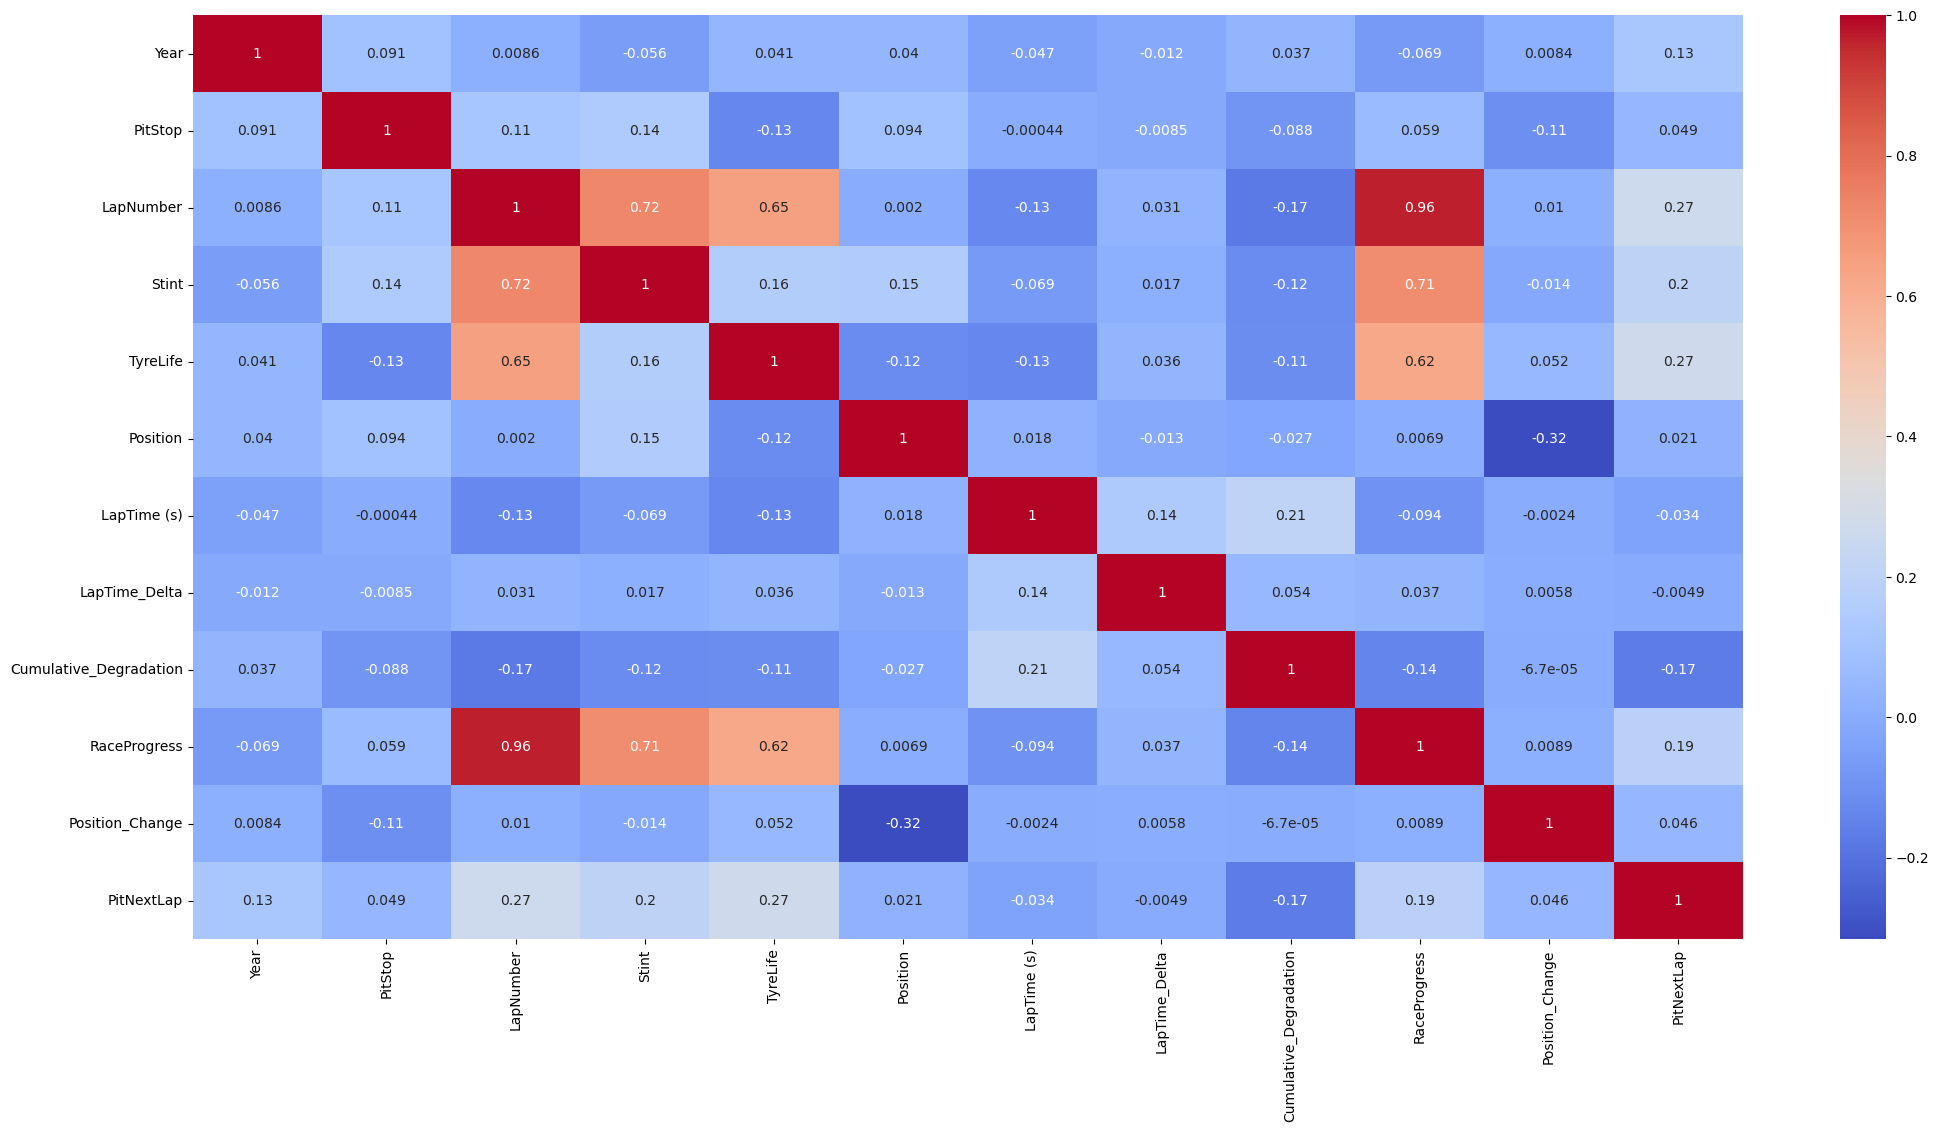

In [6]:
plt.figure(figsize=(25,12))
sns.heatmap(df_train.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.show()

In [7]:
df_train.describe(include=object)

,Driver,Compound,Race
count,439140,439140,439140
unique,887,5,26
top,MAS,MEDIUM,Dutch Grand Prix
freq,1682,211141,24462


In [8]:
pit_stop_yes = df_train[df_train["PitNextLap"] == 1] .groupby("Compound")["PitNextLap"] .size()
pit_stop_yes

Compound
HARD            55851
INTERMEDIATE     2647
MEDIUM          21353
SOFT             7496
WET                34
Name: PitNextLap, dtype: int64

In [9]:
pit_stop_no = df_train[df_train["PitNextLap"] == 0] .groupby("Compound")["PitNextLap"] .size()
pit_stop_no

Compound
HARD            114667
INTERMEDIATE     14735
MEDIUM          189788
SOFT             31248
WET               1321
Name: PitNextLap, dtype: int64

In [10]:
df_train["PitNextLap"].value_counts()

PitNextLap
0.0    351759
1.0     87381
Name: count, dtype: int64

# Feature Engineering

In [11]:
compound_map = {
    "HARD": 0,
    "INTERMEDIATE": 1,
    "MEDIUM": 2,
    "SOFT": 3,
    "WET": 4
}

df_train["Compound"] = df_train["Compound"].map(compound_map)

In [12]:
df_train.drop(columns="Driver",inplace=True)

In [13]:
df_train.groupby("Race")["PitNextLap"].count()

Race
Abu Dhabi Grand Prix         16427
Australian Grand Prix        18406
Austrian Grand Prix          21223
Azerbaijan Grand Prix        12126
Bahrain Grand Prix           19535
Belgian Grand Prix            9002
British Grand Prix           15383
Canadian Grand Prix          21416
Chinese Grand Prix            7311
Dutch Grand Prix             24462
Emilia Romagna Grand Prix    15483
French Grand Prix             3185
Hungarian Grand Prix         22481
Italian Grand Prix           19854
Japanese Grand Prix          12891
Las Vegas Grand Prix         12479
Mexico City Grand Prix       23672
Miami Grand Prix             18860
Monaco Grand Prix            21539
Pre-Season Testing           22492
Qatar Grand Prix             13817
Saudi Arabian Grand Prix     18111
Singapore Grand Prix         18960
Spanish Grand Prix           20483
São Paulo Grand Prix         11497
United States Grand Prix     18045
Name: PitNextLap, dtype: int64

In [14]:
df_train[df_train["PitNextLap"]==1].groupby("Race")["PitNextLap"] .size()

Race
Abu Dhabi Grand Prix         2473
Australian Grand Prix        3342
Austrian Grand Prix          3991
Azerbaijan Grand Prix        2602
Bahrain Grand Prix           5617
Belgian Grand Prix           2524
British Grand Prix           2053
Canadian Grand Prix          3295
Chinese Grand Prix           2841
Dutch Grand Prix             4307
Emilia Romagna Grand Prix    4220
French Grand Prix             820
Hungarian Grand Prix         5379
Italian Grand Prix           2620
Japanese Grand Prix          2630
Las Vegas Grand Prix         2812
Mexico City Grand Prix       2146
Miami Grand Prix             1953
Monaco Grand Prix            7698
Pre-Season Testing           3296
Qatar Grand Prix             2426
Saudi Arabian Grand Prix     4119
Singapore Grand Prix         2688
Spanish Grand Prix           6554
São Paulo Grand Prix         2917
United States Grand Prix     2058
Name: PitNextLap, dtype: int64

# One Hot Encoding

In [15]:
df_train = pd.get_dummies(df_train,columns=["Race"],drop_first=True)
df_train

,Compound,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,...,Race_Mexico City Grand Prix,Race_Miami Grand Prix,Race_Monaco Grand Prix,Race_Pre-Season Testing,Race_Qatar Grand Prix,Race_Saudi Arabian Grand Prix,Race_Singapore Grand Prix,Race_Spanish Grand Prix,Race_São Paulo Grand Prix,Race_United States Grand Prix
id,,,,,,,,,,,,,,,,,,,,,
0,0,2022,0,50,2,39.0,8,78.491,-7.564,21.019,...,False,False,False,False,False,False,False,False,False,False
1,0,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,...,False,False,False,False,False,False,False,False,False,False
2,0,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,...,False,False,False,False,False,False,False,False,False,False
3,2,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,...,False,False,False,True,False,False,False,False,False,False
4,0,2022,1,26,3,6.0,2,107.878,8.965,-14.139,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
439135,2,2023,0,49,2,8.0,17,92.638,-0.076,-15.859,...,False,True,False,False,False,False,False,False,False,False
439136,2,2023,0,49,2,5.0,1,85.890,-0.083,-4.907,...,False,True,False,False,False,False,False,False,False,False
439137,2,2023,0,49,2,18.0,1,91.644,-0.182,-56.371,...,False,True,False,False,False,False,False,False,False,False


In [16]:
df_train.columns

Index(['Compound', 'Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife',
       'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation',
       'RaceProgress', 'Position_Change', 'PitNextLap',
       'Race_Australian Grand Prix', 'Race_Austrian Grand Prix',
       'Race_Azerbaijan Grand Prix', 'Race_Bahrain Grand Prix',
       'Race_Belgian Grand Prix', 'Race_British Grand Prix',
       'Race_Canadian Grand Prix', 'Race_Chinese Grand Prix',
       'Race_Dutch Grand Prix', 'Race_Emilia Romagna Grand Prix',
       'Race_French Grand Prix', 'Race_Hungarian Grand Prix',
       'Race_Italian Grand Prix', 'Race_Japanese Grand Prix',
       'Race_Las Vegas Grand Prix', 'Race_Mexico City Grand Prix',
       'Race_Miami Grand Prix', 'Race_Monaco Grand Prix',
       'Race_Pre-Season Testing', 'Race_Qatar Grand Prix',
       'Race_Saudi Arabian Grand Prix', 'Race_Singapore Grand Prix',
       'Race_Spanish Grand Prix', 'Race_São Paulo Grand Prix',
       'Race_United States Grand Prix

In [17]:
df_train["Year"].value_counts()

Year
2023    136147
2024    127110
2025     92894
2022     82989
Name: count, dtype: int64

In [18]:
df_train = pd.get_dummies(
    df_train,
    columns=["Year"],
    drop_first=True
)

# Feature Scaling

In [19]:
scale_cols = [
    'LapNumber',
    'Stint',
    'TyreLife',
    'Position',
    'LapTime (s)',
    'LapTime_Delta',
    'Cumulative_Degradation',
    'RaceProgress',
    'Position_Change'
]
scaler = StandardScaler()

df_train[scale_cols] = scaler.fit_transform(df_train[scale_cols])

In [20]:
df_train

,Compound,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,...,Race_Pre-Season Testing,Race_Qatar Grand Prix,Race_Saudi Arabian Grand Prix,Race_Singapore Grand Prix,Race_Spanish Grand Prix,Race_São Paulo Grand Prix,Race_United States Grand Prix,Year_2023,Year_2024,Year_2025
id,,,,,,,,,,,,,,,,,,,,,
0,0,0,1.585901,0.221941,2.534531,-0.308849,-0.630046,-0.086333,0.853455,1.487008,...,False,False,False,False,False,False,False,False,False,False
1,0,1,0.229628,0.221941,-0.730333,-1.066602,-0.801797,-0.656423,-3.605949,0.033534,...,False,False,False,False,False,False,False,False,False,True
2,0,0,2.116616,1.274359,0.800072,0.638343,-1.011682,-0.085787,-1.365930,1.902200,...,False,False,False,False,False,False,False,False,False,False
3,2,0,-1.244581,-0.830476,-1.240468,-0.498287,0.172574,-0.080872,0.335931,-1.029455,...,True,False,False,False,False,False,False,True,False,False
4,0,1,0.170660,1.274359,-0.832360,-1.445478,0.856192,0.289790,0.211493,0.092589,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
439135,2,0,1.526932,0.221941,-0.628306,1.396096,0.085434,0.084059,0.180087,2.060938,...,False,False,False,False,False,False,False,True,False,False
439136,2,0,1.526932,0.221941,-0.934387,-1.634917,-0.255844,0.083900,0.380064,2.060938,...,False,False,False,False,False,False,False,True,False,False
439137,2,0,1.526932,0.221941,0.391964,-1.634917,0.035163,0.081647,-0.559635,2.387294,...,False,False,False,False,False,False,False,True,False,False


# Feature Selection

In [21]:
X = df_train.drop("PitNextLap", axis=1)
y = df_train["PitNextLap"]

# Train Test Split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train, X_test, y_train, y_test

(        Compound  PitStop  LapNumber     Stint  TyreLife  Position  \
 id                                                                   
 356074         2        0  -1.067676 -0.830476 -0.934387 -0.119410   
 42584          2        0  -1.126644 -0.830476 -1.036414  1.964411   
 284145         2        0  -1.244581 -0.830476 -1.240468  0.638343   
 254942         0        0   0.583438  0.221941  1.922369  1.017219   
 408579         2        0  -1.067676 -0.830476 -0.934387  1.774973   
 ...          ...      ...        ...       ...       ...       ...   
 259178         2        0  -1.303550 -0.830476 -1.342495  1.585534   
 365838         2        0  -0.890771 -0.830476 -0.628306  0.259466   
 131932         2        0   0.170660 -0.830476  1.208180 -1.256040   
 146867         2        0  -1.008708 -0.830476 -0.832360  0.827781   
 121958         1        0  -0.360056 -0.830476  0.698045  0.259466   
 
         LapTime (s)  LapTime_Delta  Cumulative_Degradation  RaceProgress  

# Model Building - Logistic Regression

In [23]:
model = LogisticRegression()

In [24]:
model.fit(X_train,y_train)

LogisticRegression()

In [25]:
model.coef_

array([[-5.13702088e-01, -2.25091926e-01,  7.66202115e-01,
         6.83552077e-01,  9.33806258e-01,  2.88068829e-02,
        -4.24409516e-01, -3.35976316e-02, -1.62865663e-01,
        -1.22407016e+00,  7.59211081e-02, -1.05971347e+00,
        -5.18434857e-01,  4.13545679e-01,  1.22115628e+00,
         1.49225516e+00,  2.96524611e-01, -1.07393026e+00,
         6.63065748e-01, -6.39127541e-01, -3.51169716e-01,
        -1.23124665e-01,  1.04541171e-01, -5.84105521e-01,
        -4.10619687e-03,  6.56431488e-01, -9.63407455e-01,
        -5.69012276e-01,  1.02904251e-02, -1.24208982e-01,
        -6.21400284e-02,  3.32818308e-01,  7.12228778e-02,
         1.19066988e+00,  2.59565265e-01, -1.17490895e-01,
        -4.44367435e+00, -4.17915082e-01, -4.05656260e-01]])

In [26]:
model.intercept_

array([-0.24060879])

# Model Prediction

In [27]:
y_pred = model.predict(X_test)
y_pred

array([0., 0., 0., ..., 0., 0., 0.])

# Model Evaluation

In [28]:
confusion_matrix(y_test,y_pred)

array([[66252,  4034],
       [ 8915,  8627]])

In [29]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.88      0.94      0.91     70286
         1.0       0.68      0.49      0.57     17542

    accuracy                           0.85     87828
   macro avg       0.78      0.72      0.74     87828
weighted avg       0.84      0.85      0.84     87828



In [30]:
accuracy_score(y_test,y_pred)

0.8525641025641025

# Test Dataset Preprocessing

In [31]:
compound_map = {
    "HARD": 0,
    "INTERMEDIATE": 1,
    "MEDIUM": 2,
    "SOFT": 3,
    "WET": 4
}

df_test["Compound"] = df_test["Compound"].map(compound_map)

In [32]:
df_test.drop(columns="Driver",inplace=True)

In [33]:
df_test = pd.get_dummies(df_test,columns=["Race"],drop_first=True)
df_test

,Compound,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,...,Race_Mexico City Grand Prix,Race_Miami Grand Prix,Race_Monaco Grand Prix,Race_Pre-Season Testing,Race_Qatar Grand Prix,Race_Saudi Arabian Grand Prix,Race_Singapore Grand Prix,Race_Spanish Grand Prix,Race_São Paulo Grand Prix,Race_United States Grand Prix
id,,,,,,,,,,,,,,,,,,,,,
439140,2,2023,0,21,1,21.0,4,93.387,0.280,-4.984,...,False,False,False,False,False,False,False,False,False,False
439141,2,2023,0,24,1,24.0,1,90.867,-0.129,-1.990,...,False,False,False,False,False,False,False,False,False,False
439142,2,2023,0,24,1,24.0,11,92.871,0.041,-8.842,...,False,False,False,False,False,False,False,False,False,False
439143,3,2024,0,6,2,4.0,15,94.967,-19.741,8.250,...,False,False,False,False,False,False,False,False,True,False
439144,0,2024,0,52,2,29.0,12,99.112,0.930,-20.848,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
627300,2,2024,1,14,1,14.0,4,83.879,-16.919,-87.767,...,False,False,False,False,False,False,False,False,False,False
627301,3,2025,0,60,3,26.0,4,95.727,7.920,-36.485,...,False,False,False,True,False,False,False,False,False,False
627302,2,2022,0,28,2,21.0,7,85.058,-14.180,-0.339,...,False,False,False,False,False,False,False,False,False,False


In [34]:
df_test = pd.get_dummies(
    df_test,
    columns=["Year"],
    drop_first=True
)

In [35]:
scale_cols = [
    'LapNumber',
    'Stint',
    'TyreLife',
    'Position',
    'LapTime (s)',
    'LapTime_Delta',
    'Cumulative_Degradation',
    'RaceProgress',
    'Position_Change'
]
scaler = StandardScaler()

df_test[scale_cols] = scaler.fit_transform(df_test[scale_cols])

# Kaggle Submission Prediction

In [36]:
y_pred = model.predict(df_test)
y_pred

array([0., 0., 0., ..., 0., 0., 0.])

In [37]:
df_sub["PitNextLap"] = y_pred
df_sub

,id,PitNextLap
0,439140,0.0
1,439141,0.0
2,439142,0.0
3,439143,0.0
4,439144,1.0
...,...,...
188160,627300,0.0
188161,627301,0.0
188162,627302,0.0
188163,627303,0.0


In [38]:
df_sub.to_csv("submission.csv", index=False)
print("submission.csv saved")

submission.csv saved


In [39]:
df_sub[df_sub["PitNextLap"] == 0].value_counts().sum(),df_sub[df_sub["PitNextLap"] == 1].value_counts().sum()

(np.int64(161286), np.int64(26879))


# Conclusion

- Successfully performed preprocessing and feature engineering on F1 race data.
- Applied encoding and scaling techniques for better model performance.
- Built a Logistic Regression model for pit stop prediction.
- Evaluated model performance using classification metrics.
- Generated a Kaggle-ready submission file.

---

## Project Type
Machine Learning | Classification | Kaggle Competition
